# Day 0: Generate the Dataset

All seven chapters in this book use the same dataset: a synthetic collection of crime incident reports set in **Nordvik**, a fictional city placed on Bouvet Island - the world's most remote uninhabited island, a Norwegian dependency in the South Atlantic. Population: zero. Crime rate: whatever we generate.

Using a fictional location on a real but uninhabited island means our coordinates are geographically coherent (distances, clustering and hotspot maps all work correctly) without implicating any real streets or residents.

We generate the dataset in two stages:

1. **Structured fields** - crime type, location, timestamps, victim and suspect characteristics - sampled from predefined value lists with realistic weights
2. **MO_TEXT** - a free-text narrative assembled from templates, grounded in the structured fields for each row

The result is saved as both CSV and Parquet for use throughout the book.

## 1. Install Dependencies

In [1]:
%pip install pandas==3.0.3 \
             plotly==6.9.0 \
             pyarrow==25.0.0 \
             tqdm==4.68.3 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import os
import pandas as pd
import plotly.express as px
import random
import re

from datetime import datetime, timedelta
from tqdm.notebook import tqdm

## 3. Configuration

In [3]:
N_RECORDS   = 500_000
RANDOM_SEED = 42
OUTPUT_DIR  = "data"

os.makedirs(OUTPUT_DIR, exist_ok = True)
random.seed(RANDOM_SEED)

FINAL_CSV_PATH = os.path.join(OUTPUT_DIR, "nordvik_crimes.csv")
FINAL_PQ_PATH  = os.path.join(OUTPUT_DIR, "nordvik_crimes.parquet")

## 4. Bouvet Island Bounding Box

Bouvet Island (54°26'S, 3°24'E) is the world's most remote uninhabited island - a Norwegian dependency in the South Atlantic, roughly 49 km² in area. Our fictional city of Nordvik occupies its footprint. Coordinates are real and spatially coherent; no people live here.

In [4]:
LAT_MIN, LAT_MAX = -54.470, -54.380
LON_MIN, LON_MAX =   3.300,   3.460

NEIGHBORHOODS = {
    "Northgate":     {"lat": -54.385, "lon": 3.310},
    "Millfield":     {"lat": -54.390, "lon": 3.340},
    "Ashbrook":      {"lat": -54.395, "lon": 3.370},
    "Hartley Cross": {"lat": -54.400, "lon": 3.395},
    "Sowerby End":   {"lat": -54.405, "lon": 3.420},
    "Pennington":    {"lat": -54.415, "lon": 3.310},
    "Daleford":      {"lat": -54.420, "lon": 3.340},
    "Westmere":      {"lat": -54.425, "lon": 3.365},
    "Cragside":      {"lat": -54.430, "lon": 3.390},
    "Brackenhill":   {"lat": -54.435, "lon": 3.415},
    "Thornwick":     {"lat": -54.445, "lon": 3.315},
    "Elmstead":      {"lat": -54.448, "lon": 3.345},
    "Ravenscar":     {"lat": -54.450, "lon": 3.370},
    "Holmfield":     {"lat": -54.455, "lon": 3.400},
    "Crowden":       {"lat": -54.460, "lon": 3.430},
}

JITTER = 0.003

def jittered_coords(neighborhood):
    centroid = NEIGHBORHOODS[neighborhood]
    lat = centroid["lat"] + random.uniform(-JITTER, JITTER)
    lon = centroid["lon"] + random.uniform(-JITTER, JITTER)
    return round(lat, 6), round(lon, 6)

print(f"OK  {len(NEIGHBORHOODS)} neighborhoods defined within Nordvik (Bouvet Island)")

OK  15 neighborhoods defined within Nordvik (Bouvet Island)


## 5. Value Lists and Weights

In [5]:
CRIME_TYPES = [
    ("Burglary",      "Forced Entry Residential",    0.15),
    ("Burglary",      "No Forced Entry Residential", 0.10),
    ("Burglary",      "Forced Entry Commercial",     0.06),
    ("Burglary",      "No Forced Entry Commercial",  0.04),
    ("Vehicle Crime", "Theft of Vehicle",            0.12),
    ("Vehicle Crime", "Theft from Vehicle",          0.08),
    ("Vehicle Crime", "Vehicle Interference",        0.05),
    ("Robbery",       "Street Robbery",              0.10),
    ("Robbery",       "Distraction Theft",           0.05),
    ("Robbery",       "Snatch Theft",                0.05),
    ("Assault",       "Common Assault",              0.06),
    ("Assault",       "Aggravated Assault",          0.04),
    ("Drug Offences", "Possession",                  0.05),
    ("Drug Offences", "Supply",                      0.02),
    ("Other",         "Criminal Damage",             0.02),
    ("Other",         "Miscellaneous",               0.01),
]

CRIME_CATEGORIES    = [c[0] for c in CRIME_TYPES]
CRIME_SUBCATEGORIES = [c[1] for c in CRIME_TYPES]
CRIME_WEIGHTS       = [c[2] for c in CRIME_TYPES]

ENTRY_METHODS = {
    "Burglary": [
        "forced rear door - screwdriver",
        "forced front door - unknown tool",
        "smashed patio door",
        "unsecured rear window",
        "unsecured side window",
        "smashed front window",
        "removed door hinges",
        "drilled lock cylinder",
        "snapped lock",
        "insecure garage door",
        "no forced entry - unknown means",
        "letter box fishing",
    ],
    "Vehicle Crime": [
        "bypass ignition wiring",
        "relay attack - keyless entry",
        "smashed driver window",
        "smashed rear window",
        "unlocked vehicle",
        "duplicate key",
        "tow away",
        "unknown",
    ],
    "Robbery":       ["none - approached victim", "unknown"],
    "Assault":       ["none", "unknown"],
    "Drug Offences": ["none", "unknown"],
    "Other":         ["unknown"],
}

WEAPONS = [
    ("none",              0.60),
    ("kitchen knife",     0.10),
    ("craft knife",       0.06),
    ("screwdriver",       0.06),
    ("baseball bat",      0.04),
    ("broken bottle",     0.04),
    ("imitation firearm", 0.04),
    ("firearm",           0.02),
    ("hammer",            0.02),
    ("metal bar",         0.02),
]
WEAPON_NAMES   = [w[0] for w in WEAPONS]
WEAPON_WEIGHTS = [w[1] for w in WEAPONS]

PROPERTY_STOLEN = {
    "Burglary": [
        "jewellery", "laptop", "cash", "passports", "watch",
        "handbag", "tablet", "car keys", "credit cards",
        "camera", "gaming console", "power tools", "spirits",
    ],
    "Vehicle Crime": [
        "catalytic converter", "stereo", "sat nav", "tools",
        "bags", "jacket", "wallet", "laptop bag", "cash",
        "vehicle - make unknown", "vehicle - Ford Transit",
        "vehicle - Vauxhall Astra", "vehicle - BMW 3 Series",
    ],
    "Robbery": [
        "mobile phone", "wallet", "handbag", "watch",
        "jewellery", "cash", "bicycle", "backpack",
    ],
    "Assault":       ["none"],
    "Drug Offences": ["controlled drugs", "cash", "drugs paraphernalia"],
    "Other":         ["none", "unknown"],
}

PROPERTY_TYPES = {
    "Burglary": [
        "Residence - Single Family",
        "Residence - Flat/Apartment",
        "Retail - Shop",
        "Retail - Off Licence",
        "Commercial - Office",
        "Commercial - Warehouse",
    ],
    "Vehicle Crime": [
        "Street - Residential",
        "Street - Commercial",
        "Parking - Multi-storey",
        "Parking - Open air",
        "Retail - Car park",
    ],
    "Robbery":       ["Street", "Park", "Public transport", "Car park"],
    "Assault":       ["Street", "Licensed premises", "Residence", "Public transport"],
    "Drug Offences": ["Street", "Residence", "Vehicle", "Public space"],
    "Other":         ["Street", "Residence", "Commercial", "Public space"],
}

SUSPECT_COUNT    = [1, 2, 3]
SUSPECT_WEIGHTS  = [0.55, 0.35, 0.10]
SUSPECT_BUILDS   = ["slim", "stocky", "medium"]
SUSPECT_HEIGHTS  = ["short", "average", "tall"]
SUSPECT_CLOTHING = [
    "dark hoodie",
    "high-vis jacket",
    "baseball cap and dark jacket",
    "face covering",
    "beanie hat and tracksuit",
    "unknown - CCTV unavailable",
]

VEHICLE_COLORS  = ["white", "blue", "grey", "black", "silver", "red", "unknown"]
VEHICLE_MAKES   = [
    "Ford Transit", "Vauxhall Astra", "BMW 3 Series",
    "VW Golf", "Audi A4", "Ford Focus", "unknown make",
]

VICTIM_GENDERS       = ["M", "F", "unknown"]
VICTIM_VULNERABILITY = ["none", "elderly", "lone female", "intoxicated", "none"]

RESIDENTIAL_PROPERTY = [
    "Residence - Single Family",
    "Residence - Flat/Apartment",
]
COMMERCIAL_PROPERTY = [
    "Retail - Shop",
    "Retail - Off Licence",
    "Commercial - Office",
    "Commercial - Warehouse",
]

print("OK  Value lists defined")

OK  Value lists defined


## 6. Row Sampler

In [6]:
def random_datetime(start_year = 2021, end_year = 2024):
    start = datetime(start_year, 1, 1)
    end   = datetime(end_year, 12, 31)
    delta = end - start
    return start + timedelta(seconds = random.randint(0, int(delta.total_seconds())))

def sample_row(incident_id):
    idx           = random.choices(range(len(CRIME_TYPES)), weights = CRIME_WEIGHTS)[0]
    crime_type    = CRIME_CATEGORIES[idx]
    crime_subtype = CRIME_SUBCATEGORIES[idx]

    neighborhood = random.choice(list(NEIGHBORHOODS.keys()))
    lat, lon     = jittered_coords(neighborhood)

    if crime_type == "Burglary":
        if "Residential" in crime_subtype:
            property_type = random.choice(RESIDENTIAL_PROPERTY)
        else:
            property_type = random.choice(COMMERCIAL_PROPERTY)
    else:
        property_type = random.choice(PROPERTY_TYPES[crime_type])

    dt = random_datetime()

    n_suspects       = random.choices(SUSPECT_COUNT, weights = SUSPECT_WEIGHTS)[0]
    suspect_build    = random.choice(SUSPECT_BUILDS)
    suspect_height   = random.choice(SUSPECT_HEIGHTS)
    suspect_clothing = random.choice(SUSPECT_CLOTHING)

    if crime_type in ("Burglary", "Vehicle Crime") and random.random() > 0.4:
        colour = random.choice(VEHICLE_COLORS)
        make   = random.choice(VEHICLE_MAKES)
        if colour == "unknown" and make == "unknown make":
            suspect_vehicle = "unknown vehicle"
        elif colour == "unknown":
            suspect_vehicle = make
        elif make == "unknown make":
            suspect_vehicle = f"{colour} vehicle"
        else:
            suspect_vehicle = f"{colour} {make}"
    else:
        suspect_vehicle = "none observed"

    victim_age           = random.randint(18, 85)
    victim_gender        = random.choice(VICTIM_GENDERS)
    victim_vulnerability = random.choice(VICTIM_VULNERABILITY)

    entry_method    = random.choice(ENTRY_METHODS[crime_type])
    weapon          = random.choices(WEAPON_NAMES, weights = WEAPON_WEIGHTS)[0]
    n_property      = random.randint(1, 3)
    property_stolen = ", ".join(
        random.sample(PROPERTY_STOLEN[crime_type],
                      min(n_property, len(PROPERTY_STOLEN[crime_type])))
    )

    return {
        "IncidentID":          str(incident_id),
        "CrimeType":           crime_type,
        "CrimeSubType":        crime_subtype,
        "Neighborhood":        neighborhood,
        "PropertyType":        property_type,
        "Latitude":            lat,
        "Longitude":           lon,
        "DateTime":            dt.strftime("%Y-%m-%d %H:%M"),
        "SuspectCount":        n_suspects,
        "SuspectBuild":        suspect_build,
        "SuspectHeight":       suspect_height,
        "SuspectClothing":     suspect_clothing,
        "SuspectVehicle":      suspect_vehicle,
        "VictimAge":           victim_age,
        "VictimGender":        victim_gender,
        "VictimVulnerability": victim_vulnerability,
        "EntryMethod":         entry_method,
        "Weapon":              weapon,
        "PropertyStolen":      property_stolen,
        "MO_TEXT":             "",
    }

sample = sample_row("TEST-001")
print("Sample row (structured fields):")
for k, v in sample.items():
    if k != "MO_TEXT":
        print(f"  {k:<22} {v}")

Sample row (structured fields):
  IncidentID             TEST-001
  CrimeType              Robbery
  CrimeSubType           Street Robbery
  Neighborhood           Northgate
  PropertyType           Park
  Latitude               -54.383551
  Longitude              3.308469
  DateTime               2024-02-19 01:38
  SuspectCount           1
  SuspectBuild           medium
  SuspectHeight          tall
  SuspectClothing        dark hoodie
  SuspectVehicle         none observed
  VictimAge              72
  VictimGender           M
  VictimVulnerability    none
  EntryMethod            none - approached victim
  Weapon                 none
  PropertyStolen         mobile phone, jewellery, wallet


## 7. Template-Based MO_TEXT Generator

Rather than an LLM we use a large set of templates grounded in the structured fields. Randomised phrasing, timestamp formats, shorthand and uncertainty language produce enough variety for realistic embeddings.

In [7]:
def fmt_time(dt_str):
    """Return hour as police-style string, e.g. 0230hrs."""
    h = dt_str[11:13]
    m = dt_str[14:16]
    return f"{h}{m}hrs"

def fmt_time_range(dt_str):
    """Return a plausible time window around the incident time."""
    h     = int(dt_str[11:13])
    start = f"{h:02d}00hrs"
    end   = f"{(h + random.randint(1, 3)) % 24:02d}00hrs"
    return start, end

def sus_desc(row):
    n    = row["SuspectCount"]
    desc = f"{row['SuspectBuild']} build, {row['SuspectHeight']}, wearing {row['SuspectClothing']}"
    if n == 1:
        return random.choice([
            f"One suspect described as {desc}",
            f"A single suspect, {desc}",
            f"Suspect described as {desc}",
            f"Unknown suspect, {desc}",
            f"Sus IC1, {desc}",
        ])
    elif n == 2:
        return random.choice([
            f"Two suspects both described as {desc}",
            f"Two offenders, {desc}",
            f"A pair of suspects, {desc}",
        ])
    else:
        return random.choice([
            f"Three or more suspects, {desc}",
            f"Multiple offenders described as {desc}",
            f"A group of suspects, {desc}",
        ])

def weapon_phrase(weapon):
    if weapon == "none":
        return ""
    return random.choice([
        f"Armed with {weapon}. ",
        f"Suspect in possession of {weapon}. ",
        f"Offender believed to be carrying {weapon}. ",
        f"{weapon.capitalize()} used during incident. ",
        f"Weapon: {weapon}. ",
    ])

def vehicle_phrase(veh):
    if veh == "none observed":
        return ""
    return random.choice([
        f"Suspect vehicle: {veh}. ",
        f"Left scene in {veh}. ",
        f"Offenders seen leaving in {veh}. ",
        f"CCTV shows {veh} in area. ",
        f"Possible suspect vehicle {veh} noted in area. ",
    ])

def property_phrase(row):
    prop       = row["PropertyStolen"]
    crime_type = row["CrimeType"]
    if not prop or all(p.strip() in ("none", "unknown") for p in prop.split(",")):
        return random.choice([
            "No property reported stolen. ",
            "Nothing taken. ",
            "Property stolen unknown at this time. ",
        ])
    if crime_type == "Drug Offences":
        return random.choice([
            f"Found in possession of {prop}. ",
            f"In possession of {prop}. ",
            f"{prop.capitalize()} recovered. ",
            f"Drugs recovered: {prop}. ",
        ])
    return random.choice([
        f"Property taken: {prop}. ",
        f"Stolen: {prop}. ",
        f"Items removed include {prop}. ",
        f"Offender(s) made off with {prop}. ",
        f"{prop.capitalize()} reported stolen. ",
    ])

def entry_phrase(row):
    method = row["EntryMethod"]
    if any(x in method.lower() for x in ("none", "unknown", "no forced entry", "tow away")):
        return ""
    return random.choice([
        f"Entry gained via {method}. ",
        f"Offender entered by {method}. ",
        f"Point of entry: {method}. ",
        f"Believed to have entered using {method}. ",
        f"Access via {method}. ",
    ])

def forensic_note():
    return random.choice([
        "No FO identified. ",
        "CCTV req. ",
        "Scene examined - no forensic opportunities. ",
        "Fingerprints taken. ",
        "No witnesses at time of offence. ",
        "",
        "",
        "",
    ])

def uncertainty():
    return random.choice([
        "believed to have ",
        "possibly ",
        "suspected to have ",
        "",
        "",
    ])

def generate_mo_text(row):
    t          = fmt_time(row["DateTime"])
    t1, t2     = fmt_time_range(row["DateTime"])
    loc        = row["Neighborhood"]
    prop_t     = row["PropertyType"]
    crime      = row["CrimeSubType"]
    sus        = sus_desc(row)
    sus_lc     = sus[0].lower() + sus[1:]
    wpn        = weapon_phrase(row["Weapon"])
    veh        = vehicle_phrase(row["SuspectVehicle"])
    prop       = property_phrase(row)
    entry      = entry_phrase(row)
    fo         = forensic_note()
    unc        = uncertainty()
    crime_type = row["CrimeType"]

    age         = row["VictimAge"]
    gender      = row["VictimGender"]
    vuln        = row["VictimVulnerability"] if crime_type in ("Robbery", "Assault") else "none"
    gender_word = {"M": "male", "F": "female", "unknown": "unknown gender"}.get(gender, "unknown")
    vic_base    = random.choice([
        f"Victim {gender_word} approx {age}yrs.",
        f"V/{gender} aged approx {age}.",
        f"Complainant: {gender_word}, {age} years.",
        f"Victim described as {gender_word}, mid-{(age // 10) * 10}s.",
    ])
    if vuln != "none":
        vic_base += random.choice([
            f" Victim noted as {vuln}.",
            f" Vulnerability: {vuln}.",
            f" V flagged as {vuln}.",
        ])
    vic = vic_base

    crime_label = {
        "Forced Entry Residential":    "burglary",
        "No Forced Entry Residential": "burglary",
        "Forced Entry Commercial":     "commercial burglary",
        "No Forced Entry Commercial":  "commercial burglary",
        "Theft of Vehicle":            "vehicle theft",
        "Theft from Vehicle":          "theft from vehicle",
        "Vehicle Interference":        "vehicle interference",
        "Street Robbery":              "street robbery",
        "Distraction Theft":           "distraction theft",
        "Snatch Theft":                "snatch theft",
        "Common Assault":              "common assault",
        "Aggravated Assault":          "aggravated assault",
        "Possession":                  "drug possession",
        "Supply":                      "drug supply",
        "Criminal Damage":             "criminal damage",
        "Miscellaneous":               "miscellaneous incident",
    }.get(crime, crime.lower())

    if crime_type == "Burglary":
        templates = [
            f"At approx {t}, {sus} gained entry to {prop_t} in {loc}. {entry}{prop}{wpn}{veh}{fo}",
            f"Between {t1} and {t2}, offender(s) {unc}entered {prop_t} in {loc}. {entry}{prop}{wpn}{veh}{fo}",
            f"Offr att {prop_t} in {loc} re: {crime_label} at approx {t}. {entry}{sus}. {prop}{wpn}{fo}",
            f"Occupant returned to find {prop_t} in {loc} had been entered. {entry}{prop}{sus}. {veh}{fo}",
            f"{crime_label.capitalize()} at {prop_t}, {loc}. Time: approx {t}. {sus}. {entry}{prop}{wpn}{veh}{fo}",
            f"Householder reports {crime_label} at {prop_t} in {loc} between {t1} and {t2}. {entry}{prop}{sus}. {fo}",
            f"{sus} {unc}entered {prop_t}, {loc} at {t}. {entry}{prop}{wpn}{veh}{fo}",
            f"CCTV shows {sus_lc} at {prop_t}, {loc} at approx {t}. {entry}{prop}{wpn}{fo}",
            f"Neighbour reports suspicious activity at {prop_t} in {loc} between {t1} and {t2}. {sus}. {prop}{fo}",
            f"{prop_t} in {loc} targeted. {entry}{prop}{wpn}{sus}. {veh}{fo}",
        ]

    elif crime_type == "Vehicle Crime":
        templates = [
            f"At approx {t}, {sus} targeted {prop_t} in {loc}. {entry}{prop}{wpn}{veh}{fo}",
            f"Between {t1} and {t2}, vehicle {unc}interfered with at {prop_t}, {loc}. {entry}{prop}{sus}. {fo}",
            f"Offr att {prop_t}, {loc} re: {crime_label} at {t}. {sus}. {entry}{prop}{wpn}{fo}",
            f"Owner returned to find vehicle at {prop_t} in {loc} had been broken into. {entry}{prop}{sus}. {fo}",
            f"{crime_label.capitalize()} at {prop_t}, {loc} between {t1} and {t2}. {sus}. {entry}{prop}{wpn}{veh}{fo}",
            f"Vehicle targeted at {prop_t} in {loc} at approx {t}. {sus}. {entry}{prop}{wpn}{fo}",
            f"CCTV shows {sus_lc} at {prop_t}, {loc} at {t}. {entry}{prop}{wpn}{veh}{fo}",
            f"{sus} seen at {prop_t}, {loc} between {t1} and {t2}. {entry}{prop}{fo}",
            f"{prop_t} in {loc} - {crime_label} at approx {t}. {sus}. {entry}{prop}{wpn}{veh}{fo}",
            f"Victim reports {crime_label} at {prop_t}, {loc}. {sus}. {entry}{prop}{wpn}{fo}",
        ]

    elif crime_type == "Robbery":
        templates = [
            f"At approx {t}, {sus} approached victim at {prop_t} in {loc}. {wpn}{prop}{vic}",
            f"Victim reports being approached by {sus_lc} at {prop_t}, {loc} at {t}. {wpn}{prop}{vic}",
            f"{crime_label.capitalize()} at {prop_t}, {loc} at approx {t}. {sus}. {wpn}{prop}{veh}{vic}",
            f"V/stmt: {sus_lc} approached victim at {prop_t}, {loc} at approx {t}. {wpn}{prop}{vic}",
            f"Between {t1} and {t2}, {sus_lc} targeted victim at {prop_t} in {loc}. {wpn}{prop}{vic}",
            f"Offr att {prop_t}, {loc} re: {crime_label} at {t}. {sus}. {wpn}{prop}{vic}",
            f"{sus} confronted victim at {prop_t} in {loc} at approx {t}. {wpn}{prop}{fo}",
            f"Victim states {sus_lc} approached at {prop_t}, {loc}. {wpn}{prop}{veh}{vic}",
            f"{crime_label.capitalize()} - {prop_t}, {loc}. Time: {t}. {sus}. {wpn}{prop}{vic}",
            f"Complainant reports {sus_lc} demanded property at {prop_t} in {loc} at {t}. {wpn}{prop}{vic}",
        ]

    elif crime_type == "Assault":
        templates = [
            f"At approx {t}, {sus} assaulted victim at {prop_t} in {loc}. {wpn}{vic}",
            f"Victim reports being assaulted by {sus_lc} at {prop_t}, {loc} at {t}. {wpn}{vic}",
            f"{crime_label.capitalize()} at {prop_t}, {loc} at approx {t}. {sus}. {wpn}{vic}",
            f"Offr att {prop_t}, {loc} re: {crime_label} at {t}. {sus}. {wpn}{vic}",
            f"Between {t1} and {t2}, {sus_lc} assaulted victim at {prop_t} in {loc}. {wpn}{vic}",
            f"V/stmt: {sus} assaulted victim at {prop_t}, {loc} at approx {t}. {wpn}{fo}",
            f"{sus} involved in altercation at {prop_t} in {loc} at {t}. {wpn}{vic}",
            f"Complainant reports assault by {sus_lc} at {prop_t}, {loc}. {wpn}{vic}",
            f"{crime_label.capitalize()} - {prop_t}, {loc}. Time: {t}. {sus}. {wpn}{vic}",
            f"Witness reports {sus_lc} assaulting victim at {prop_t} in {loc} at approx {t}. {wpn}{fo}",
        ]

    elif crime_type == "Drug Offences":
        templates = [
            f"At approx {t}, {sus} found in possession at {prop_t} in {loc}. {prop}{fo}",
            f"Offr att {prop_t}, {loc} at {t} re: suspicious activity. {sus}. {prop}{fo}",
            f"{crime_label.capitalize()} - {prop_t}, {loc} at approx {t}. {sus}. {prop}{fo}",
            f"Sus stop/search at {prop_t}, {loc} at {t}. {sus}. {prop}{fo}",
            f"Between {t1} and {t2}, {sus_lc} observed at {prop_t} in {loc}. {prop}{fo}",
            f"{sus} detained at {prop_t}, {loc} at approx {t}. {prop}{fo}",
            f"Intel-led stop at {prop_t} in {loc} at {t}. {sus}. {prop}{fo}",
            f"Offr obs {sus_lc} at {prop_t}, {loc} at {t}. {prop}{fo}",
            f"{crime_label.capitalize()} at {prop_t}, {loc}. {sus} found in possession. {prop}{fo}",
            f"Proactive patrol at {prop_t}, {loc} at approx {t}. {sus}. {prop}{fo}",
        ]

    else:  # Other
        templates = [
            f"At approx {t}, {sus} attended {prop_t} in {loc}. {prop}{wpn}{fo}",
            f"Offr att {prop_t}, {loc} at {t} re: {crime_label}. {sus}. {prop}{fo}",
            f"{crime_label.capitalize()} reported at {prop_t} in {loc} at approx {t}. {sus}. {prop}{fo}",
            f"Between {t1} and {t2}, incident at {prop_t}, {loc}. {sus}. {prop}{fo}",
            f"Complainant reports {crime_label} at {prop_t} in {loc}. {sus}. {prop}{fo}",
            f"{sus} involved in {crime_label} at {prop_t}, {loc} at {t}. {prop}{fo}",
            f"Report of {crime_label} at {prop_t} in {loc} at approx {t}. {sus}. {fo}",
            f"Offr att {prop_t}, {loc} re: {crime_label}. {sus}. {prop}{fo}",
            f"{crime_label.capitalize()} - {prop_t}, {loc} at {t}. {sus}. {prop}{fo}",
            f"Incident reported at {prop_t} in {loc} between {t1} and {t2}. {sus}. {prop}{fo}",
        ]

    text = random.choice(templates)
    text = re.sub(r" +", " ", text).strip()
    return text

# Smoke test
print("Sample MO_TEXT outputs:\n")
for i in range(5):
    test_row = sample_row(f"TEST-{i:03d}")
    print(f"  [{i + 1}] {generate_mo_text(test_row)}")
    print()

Sample MO_TEXT outputs:

  [1] Victim reports being approached by two suspects both described as slim build, tall, wearing face covering at Public transport, Elmstead at 0945hrs. Offender believed to be carrying firearm. Items removed include wallet, mobile phone. Victim described as female, mid-60s. V flagged as elderly.

  [2] Offr att Commercial, Daleford at 2114hrs re: criminal damage. Suspect described as slim build, short, wearing unknown - CCTV unavailable. Nothing taken.

  [3] Victim states suspect described as medium build, tall, wearing beanie hat and tracksuit approached at Car park, Ashbrook. Property taken: cash. Complainant: unknown gender, 46 years. Victim noted as lone female.

  [4] Victim reports vehicle theft at Street - Commercial, Crowden. A pair of suspects, medium build, average, wearing unknown - CCTV unavailable. Offender(s) made off with stereo. CCTV req.

  [5] Miscellaneous incident reported at Street in Cragside at approx 1848hrs. Two suspects both describ

## 8. Generate the Full Dataset

In [8]:
rows = [sample_row(f"NVK-{i:06d}") for i in range(1, N_RECORDS + 1)]
print(f"OK  {len(rows):,} rows sampled")

OK  500,000 rows sampled


In [9]:
for i in tqdm(range(len(rows)), desc = "Generating MO_TEXT"):
    rows[i]["MO_TEXT"] = generate_mo_text(rows[i])

print("\nOK  Generation complete")

Generating MO_TEXT:   0%|          | 0/500000 [00:00<?, ?it/s]


OK  Generation complete


## 9. Save Final Dataset

In [10]:
df = pd.DataFrame(rows)

df.to_csv(FINAL_CSV_PATH, index = False)
df.to_parquet(FINAL_PQ_PATH, index = False)

print(f"OK  Saved {len(df):,} rows")
print(f"    CSV:     {FINAL_CSV_PATH}")
print(f"    Parquet: {FINAL_PQ_PATH}")

OK  Saved 500,000 rows
    CSV:     data/nordvik_crimes.csv
    Parquet: data/nordvik_crimes.parquet


## 10. Dataset Summary

In [11]:
print(f"Total rows:   {len(df):,}")
print(f"Columns:      {list(df.columns)}")
print(f"Date range:   {df['DateTime'].min()} to {df['DateTime'].max()}")
print(f"Lat range:    {df['Latitude'].min():.4f} to {df['Latitude'].max():.4f}")
print(f"Lon range:    {df['Longitude'].min():.4f} to {df['Longitude'].max():.4f}")
print()
print("Crime type distribution:")
print(df["CrimeType"].value_counts().to_string())
print()
print("MO_TEXT length (words):")
df["mo_word_count"] = df["MO_TEXT"].str.split().str.len()
print(df["mo_word_count"].describe()[["min", "mean", "max"]].round(1).to_string())

Total rows:   500,000
Columns:      ['IncidentID', 'CrimeType', 'CrimeSubType', 'Neighborhood', 'PropertyType', 'Latitude', 'Longitude', 'DateTime', 'SuspectCount', 'SuspectBuild', 'SuspectHeight', 'SuspectClothing', 'SuspectVehicle', 'VictimAge', 'VictimGender', 'VictimVulnerability', 'EntryMethod', 'Weapon', 'PropertyStolen', 'MO_TEXT']
Date range:   2021-01-01 00:00 to 2024-12-30 23:59
Lat range:    -54.4630 to -54.3820
Lon range:    3.3070 to 3.4330

Crime type distribution:
CrimeType
Burglary         175277
Vehicle Crime    124934
Robbery          100038
Assault           49869
Drug Offences     34979
Other             14903

MO_TEXT length (words):
min     14.0
mean    34.5
max     66.0


In [12]:
print("Sample MO_TEXT narratives by crime type:\n")
for crime_type in df["CrimeType"].unique():
    sample = df[df["CrimeType"] == crime_type]["MO_TEXT"].sample(1).values[0]
    print(f"[{crime_type}]")
    print(f"  {sample}")
    print()

Sample MO_TEXT narratives by crime type:

[Vehicle Crime]
  Victim reports vehicle interference at Street - Residential, Ashbrook. One suspect described as medium build, short, wearing high-vis jacket. Stolen: vehicle - BMW 3 Series, jacket. CCTV req.

[Assault]
  At approx 0648hrs, Unknown suspect, medium build, average, wearing unknown - CCTV unavailable assaulted victim at Residence in Brackenhill. Victim described as unknown gender, mid-30s.

[Burglary]
  Householder reports burglary at Residence - Single Family in Westmere between 2000hrs and 2300hrs. Believed to have entered using snapped lock. Offender(s) made off with power tools, cash. Sus IC1, medium build, short, wearing high-vis jacket. CCTV req.

[Robbery]
  Street robbery - Park, Hartley Cross. Time: 1002hrs. Sus IC1, slim build, tall, wearing dark hoodie. Weapon: metal bar. Items removed include handbag. V/F aged approx 52.

[Drug Offences]
  Offr obs a pair of suspects, medium build, tall, wearing dark hoodie at Public 

## 11. Neighborhood Map

A quick sanity check - plot incident locations to confirm the spatial distribution looks like a plausible city layout.

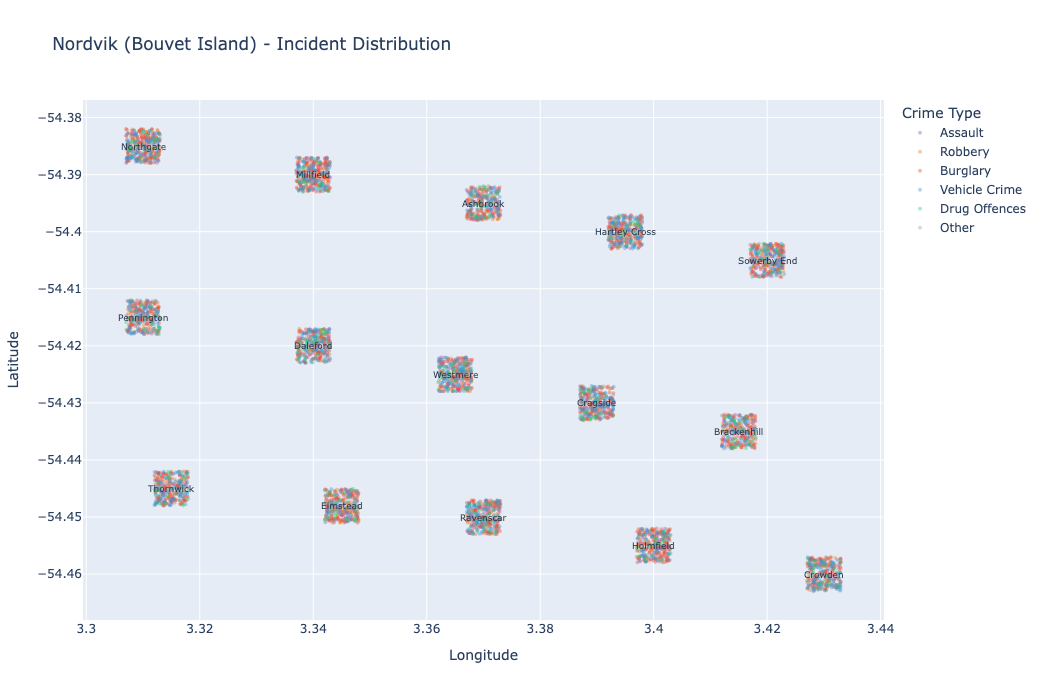

OK  Map saved to data/nordvik_incident_map.html


In [13]:
color_map = {
    "Burglary":      "#e74c3c",
    "Vehicle Crime": "#3498db",
    "Robbery":       "#e67e22",
    "Assault":       "#9b59b6",
    "Drug Offences": "#2ecc71",
    "Other":         "#95a5a6",
}

sample_df = df.sample(min(5_000, len(df)), random_state = RANDOM_SEED)

fig = px.scatter(
    sample_df,
    x = "Longitude",
    y = "Latitude",
    color = "CrimeType",
    color_discrete_map = color_map,
    opacity = 0.4,
    title = "Nordvik (Bouvet Island) - Incident Distribution",
    hover_data = ["Neighborhood", "CrimeSubType", "DateTime"],
)

# Annotate neighbourhood centroids
for name, coords in NEIGHBORHOODS.items():
    fig.add_annotation(
        x = coords["lon"],
        y = coords["lat"],
        text = name,
        showarrow = False,
        font = {"size": 9, "color": "#2c3e50"},
    )

fig.update_traces(marker = {"size": 4})
fig.update_layout(
    width = 900,
    height = 700,
    legend_title_text = "Crime Type",
)
fig.write_html(os.path.join(OUTPUT_DIR, "nordvik_incident_map.html"))
fig.show()
print("OK  Map saved to data/nordvik_incident_map.html")

## Dataset Ready

| File | Format | Use |
|---|---|---|
| `nordvik_crimes.csv` | CSV | General use and easy inspection |
| `nordvik_crimes.parquet` | Parquet | Faster loading in later chapters |

| Field | Role |
|---|---|
| `MO_TEXT` | Primary embedding field - free-text officer narrative |
| `CrimeType` | Ground truth label for recall evaluation |
| `CrimeSubType` | Finer-grained label for cluster analysis |
| `Latitude` / `Longitude` | Spatial queries and hotspot mapping |
| `DateTime` | Temporal queries and anomaly detection |